# Full Code Notebook for Vis. 6-12

In [1]:
# Import Cell
import os
os.chdir("/Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-bench/monsoonbench")

from metrics import (
    ClimatologyOnsetMetrics,
    DeterministicOnsetMetrics,
    ProbabilisticOnsetMetrics
)

from visualization.rajat_prob_code import *

from spatial.regions import get_india_outline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Polygon
import matplotlib.colors as colors
import warnings
warnings.filterwarnings('ignore')
from visualization.plot_config import params
import xarray as xr
plt.rcParams.update(params)

✓ LaTeX found at: /Library/TeX/texbin/latex
🎨 Scientific plotting configuration loaded
   LaTeX support: ✓ Enabled
   Default save format: png
   Contour levels: 100
   Colormap: bwr


In [2]:
import sys
import importlib.util

# Load the module from your local file
spec = importlib.util.spec_from_file_location(
    "probabilistic_local", 
    '/Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-bench/monsoonbench/metrics/probabilistic.py'  # Update this path
)
probabilistic_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(probabilistic_module)

# Now use the class from your local file
ProbabilisticOnsetMetrics = probabilistic_module.ProbabilisticOnsetMetrics

# Test it
print([m for m in dir(ProbabilisticOnsetMetrics) if not m.startswith('_')])

['calculate_auc', 'calculate_brier_score', 'calculate_rps', 'calculate_skill_scores', 'compute_mean_onset_for_all_members', 'compute_metrics_multiple_years', 'compute_metrics_multiple_years_from_loaders', 'compute_onset_for_all_members', 'compute_onset_metrics_with_windows', 'create_forecast_observation_pairs_with_bins', 'create_spatial_far_mr_mae', 'detect_observed_onset', 'get_forecast_probabilistic_twice_weekly', 'get_forecast_probabilistic_twice_weekly_2', 'get_india_outline', 'load_imd_rainfall', 'multi_year_forecast_obs_pairs', 'plot_spatial_metrics']


In [3]:
# config

config = {
    "imd_folder": '/Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data/imd_rainfall_data/4p0',
    "thresh_file": '/Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data/imd_onset_threshold/mwset4x4.nc4',
    "years": [
        2019,
        2020,
        2021,
        2022,
        2023,
        2024
    ],
    "alt_recent_years": np.arange(2013, 2019),
    "india_shpfile": '/Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data/ind_map_shpfile/india_shapefile.shp'
}

parent_dir = '/Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data'
det_model_paths = {
    "AIFS": f"{parent_dir}/model_forecast_data/aifs/tp_4p0_lsm",
    "FuXi": f"{parent_dir}/model_forecast_data/fuxi/output_daily_paper_0z_4p0/tp_lsm",
    "Graphcast": f"{parent_dir}/model_forecast_data/graphcast37/output_twice_weekly_paper_0z_4p0/tp_lsm",
    "NGCM": f'{parent_dir}/model_forecast_data/ngcm51/twice_weekly_0z/tp_4p0',
}
prob_model_paths = {
    "IFS": f"{parent_dir}/model_forecast_data/IFS-S2S/tp_4p0",
    "GenCast": f"{parent_dir}/model_forecast_data/gencast52/tp_lsm_4p0",
}

brier_model_paths = {
    "IFS": f"{parent_dir}/model_forecast_data/IFS-S2S/tp_4p0",
    "NGCM": f'{parent_dir}/model_forecast_data/ngcm51/twice_weekly_0z/tp_4p0',
}


model_dfs = {}
model_onsets = {}

In [4]:
thresh_slice = xr.open_dataset(config["thresh_file"])["MWmean"]
# p_model, inits = get_forecast_probabilistic_twice_weekly(
#     2013,
#     model_forecast_dir=prob_model_paths["IFS"],
#     mem_num=10,
#     file_pattern="{}.nc"
# )

# rainfall = load_imd_rainfall(
#     2013,
#     imd_folder=config["imd_folder"]
# )

# onset_da = detect_observed_onset(
#     rainfall_ds=rainfall,
#     thresh_slice=thresh_slice,
#     year=2013
# )

# onset_df = compute_onset_for_all_members(
#     p_model=p_model,
#     thresh_slice=thresh_slice,
#     onset_da=onset_da
# )

In [5]:
error_models = []

forecast_dfs_15 = {}
forecast_dfs_30 = {}
for model_name, model_fp in brier_model_paths.items():
    multi_year_df = multi_year_forecast_obs_pairs(
            config["alt_recent_years"],
            model_forecast_dir=model_fp,
            imd_folder=config["imd_folder"],
            thres_file=config["thresh_file"],
            mem_num=10,
            max_forecast_day=15,
            day_bins=[(1, 5), (6, 10), (11, 15)],
            cmz_only=False
        )
    forecast_dfs_15[model_name] = multi_year_df

    multi_year_df = multi_year_forecast_obs_pairs(
            config["alt_recent_years"],
            model_forecast_dir=model_fp,
            imd_folder=config["imd_folder"],
            thres_file=config["thresh_file"],
            mem_num=10,
            max_forecast_day=30,
            day_bins=[(1, 10), (11, 20), (21, 30)],
            cmz_only=False
        )
    forecast_dfs_30[model_name] = multi_year_df
  

Processing years: [2013 2014 2015 2016 2017 2018]

Processing year 2013
Loading S2S model data...
Loading IMD rainfall data...
Loading IMD rainfall from: /Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data/imd_rainfall_data/4p0/2013.nc
Renamed dimensions: {'TIME': 'time'}
Detecting observed onset...
Using MOK date (June 2nd) as start date for onset detection
Found onset in 35 out of 72 grid points
Computing onset for all ensemble members...
Processing 26 init times x 72 unique locations x 10 members...
Unique lat-lon pairs: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (5, 0), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), (5, 8), (6, 0), (6, 1),

In [6]:
def calculate_gridwise_brier(forecast_obs_df):
    """
    Calculate Brier Score and Fair Brier Score for each grid point (lat, lon).
    
    Parameters:
    -----------
    forecast_obs_df : DataFrame
        Output from create_forecast_observation_pairs_with_bins()
        Must contain columns: 'lat', 'lon', 'predicted_prob', 'observed_onset', 'total_members'
    
    Returns:
    --------
    xarray.DataArray with dimensions (lat, lon) containing gridwise Brier scores
    """

    results_list = []
    unique_locs = forecast_obs_df[['lat', 'lon']].drop_duplicates()
    for idx, row in unique_locs.iterrows():
        lat = row['lat']
        lon = row['lon']
        
        # Filter data for this grid point
        grid_data = forecast_obs_df[(forecast_obs_df['lat'] == lat) & 
                                     (forecast_obs_df['lon'] == lon)]
        

        loop_res = calculate_brier_score(grid_data)

        loop_dict = {
            "lat": lat,
            "lon": lon,
            "brier_score": loop_res["brier_score"],
            "fair_brier_score": loop_res["fair_brier_score"]
        }
        results_list.append(loop_dict)

    results_df = pd.DataFrame(results_list).set_index(
        ["lat", "lon"]
    )
    results_ds = results_df.to_xarray()
    
    return results_ds


def calculate_gridwise_rps(forecast_obs_df):
    """
    Calculate RPS and Fair RPS for each grid point (lat, lon).
    
    Parameters:
    -----------
    forecast_obs_df : DataFrame
        Output from create_forecast_observation_pairs_with_bins()
        Must contain columns: 'lat', 'lon', 'predicted_prob', 'observed_onset', 'total_members'
    
    Returns:
    --------
    xarray.DataArray with dimensions (lat, lon) containing gridwise RPS scores
    """

    results_list = []
    unique_locs = forecast_obs_df[['lat', 'lon']].drop_duplicates()
    for idx, row in unique_locs.iterrows():
        lat = row['lat']
        lon = row['lon']
        
        # Filter data for this grid point
        grid_data = forecast_obs_df[(forecast_obs_df['lat'] == lat) & 
                                     (forecast_obs_df['lon'] == lon)]
        

        loop_res = calculate_rps(grid_data)

        loop_dict = {
            "lat": lat,
            "lon": lon,
            "rps": loop_res["rps"],
            "fair_rps": loop_res["fair_rps"]
        }
        results_list.append(loop_dict)

    results_df = pd.DataFrame(results_list).set_index(
        ["lat", "lon"]
    )
    results_ds = results_df.to_xarray()
    
    return results_ds

In [7]:
brier_15_ds = {}
brier_30_ds = {}
rps_15_ds = {}
rps_30_ds = {}

for model, df in forecast_dfs_15.items():
    loop_grid_brier = calculate_gridwise_brier(df)
    brier_15_ds[model] = loop_grid_brier

for model, df in forecast_dfs_30.items():
    loop_grid_brier = calculate_gridwise_brier(df)
    brier_30_ds[model] = loop_grid_brier

for model, df in forecast_dfs_15.items():
    loop_grid_rps = calculate_gridwise_rps(df)
    rps_15_ds[model] = loop_grid_rps


for model, df in forecast_dfs_30.items():
    loop_grid_rps = calculate_gridwise_rps(df)
    rps_30_ds[model] = loop_grid_rps

Brier Score: 0.0144
Fair Brier Score: 0.0133
Brier Score: 0.1640
Fair Brier Score: 0.1542
Brier Score: 0.0481
Fair Brier Score: 0.0461
Brier Score: 0.0932
Fair Brier Score: 0.0875
Brier Score: 0.0590
Fair Brier Score: 0.0527
Brier Score: 0.0307
Fair Brier Score: 0.0272
Brier Score: 0.0486
Fair Brier Score: 0.0428
Brier Score: 0.0740
Fair Brier Score: 0.0690
Brier Score: 0.0915
Fair Brier Score: 0.0866
Brier Score: 0.0686
Fair Brier Score: 0.0619
Brier Score: 0.0681
Fair Brier Score: 0.0615
Brier Score: 0.0877
Fair Brier Score: 0.0824
Brier Score: 0.1128
Fair Brier Score: 0.1069
Brier Score: 0.0867
Fair Brier Score: 0.0811
Brier Score: 0.0577
Fair Brier Score: 0.0525
Brier Score: 0.0674
Fair Brier Score: 0.0622
Brier Score: 0.0768
Fair Brier Score: 0.0701
Brier Score: 0.0764
Fair Brier Score: 0.0700
Brier Score: 0.1186
Fair Brier Score: 0.1123
Brier Score: 0.1147
Fair Brier Score: 0.1090
Brier Score: 0.1208
Fair Brier Score: 0.1166
Brier Score: 0.2279
Fair Brier Score: 0.2259
Brier Scor

In [8]:
brier_15_ds

{'IFS': <xarray.Dataset> Size: 1kB
 Dimensions:           (lat: 8, lon: 8)
 Coordinates:
   * lat               (lat) float64 64B 8.0 12.0 16.0 20.0 24.0 28.0 32.0 36.0
   * lon               (lon) float64 64B 68.0 72.0 76.0 80.0 84.0 88.0 92.0 96.0
 Data variables:
     brier_score       (lat, lon) float64 512B nan nan 0.01439 ... nan nan nan
     fair_brier_score  (lat, lon) float64 512B nan nan 0.01326 ... nan nan nan,
 'NGCM': <xarray.Dataset> Size: 1kB
 Dimensions:           (lat: 8, lon: 8)
 Coordinates:
   * lat               (lat) float64 64B 8.0 12.0 16.0 20.0 24.0 28.0 32.0 36.0
   * lon               (lon) float64 64B 68.0 72.0 76.0 80.0 84.0 88.0 92.0 96.0
 Data variables:
     brier_score       (lat, lon) float64 512B nan nan 0.03272 ... nan nan nan
     fair_brier_score  (lat, lon) float64 512B nan nan 0.02797 ... nan nan nan}

In [9]:

model_labels = {"IFS":"IFS"}
# Plot configuration
SMALL_SIZE = 6
MEDIUM_SIZE = 7
LARGE_SIZE = 8

# Define Core Monsoon Zone polygon (same as reference)
polygon1_lon = np.array([86, 74, 74, 70, 70, 82, 82, 86, 86])
polygon1_lat = np.array([18, 18, 22, 22, 30, 30, 26, 26, 18])

panel_linewidth = 0.5
map_lw = 0.5
polygon_lw = 1.3
tick_length = 2
tick_width = 0.5



def cmz_text_formatter(val:float,
                       metric:str):
    if "mae" in metric:
        metric_text = f'MAE: {val:.1f}'
    elif metric == "false_alarm_rate":
        metric_text = f'FAR: {val:.2f}' 
    elif metric == "miss_rate":
        metric_text = f'MR: {val:.2f}'
    elif metric == "brier_score":
        metric_text = f'Brier: {val:.2f}'
    elif metric == "rps":
        metric_text = f'RPS: {val:.2f}'
    return metric_text

def create_discrete_colormap(levels, base_cmap='RdBu'):
    """Create a discrete colormap with specified levels"""
    cmap = plt.cm.get_cmap(base_cmap)
    norm = colors.BoundaryNorm(levels, cmap.N, clip=True)
    return cmap, norm

def create_skill_map_panel_xr(ax, data_array, model,
                              metric:str,
                              vmin=-100, vmax=100, show_ylabel=True,
                              show_xlabel=True,
                              title=None,
                              levels=None,
                              cmap='YlOrRd'
                              ):
    """
    Create a skill map panel using xarray DataArray with India boundaries
    """
    
    if data_array.isnull().all():
        ax.text(0.5, 0.5, f'No data for {model}', 
                transform=ax.transAxes, ha='center', va='center')
        return None
    
    # Get coordinates
    lats = data_array.lat.values
    lons = data_array.lon.values
    
    # Create edges for pcolormesh
    lat_edges = np.concatenate([lats - 2, [lats[-1] + 2]])
    lon_edges = np.concatenate([lons - 2, [lons[-1] + 2]])

    # Create discrete colormap and normalization
    if levels is not None:
        cmap, norm = create_discrete_colormap(levels, cmap)
        vmin, vmax = None, None  # Let norm handle the range
    else:
        cmap = cmap
        norm = None
        vmin, vmax = vmin, vmax
    
    # Create pcolormesh plot
    im = ax.pcolormesh(lon_edges, lat_edges, data_array.values,
                      transform=ccrs.PlateCarree(),
                      cmap=cmap, norm=norm, vmin=vmin, vmax=vmax, shading='flat')
    
    # for i, lat in enumerate(lats):
    #     for j, lon in enumerate(lons):
    #         value = data_array.values[i, j]
    #         if not np.isnan(value):
    #             ax.text(
    #                 lon, lat,                   # position in map coordinates
    #                 f"{value:.2f}",             # format the value
    #                 color="black",              # text color (choose 'white' if background is dark)
    #                 fontsize=6,                 # adjust size to fit
    #                 ha="center", va="center"    # center text in the cell
    #             )
    
    # Add India boundaries using the get_india_outline function
    try:
        india_boundaries = get_india_outline(
            shp_file_path=config["india_shpfile"]
        )
        for boundary in india_boundaries:
            india_lon, india_lat = boundary
            ax.plot(india_lon, india_lat, color='black', linewidth=map_lw, 
                   transform=ccrs.PlateCarree())
    except Exception as e:
        print(f"Warning: Could not load India boundaries: {e}")
        # Fallback to coastlines if India outline fails
        ax.add_feature(cfeature.COASTLINE, linewidth=map_lw, color='black')
    
    # Add Core Monsoon Zone polygon
    polygon = Polygon(list(zip(polygon1_lon, polygon1_lat)), 
                     fill=False, edgecolor='black', linewidth=polygon_lw,
                     transform=ccrs.PlateCarree())
    ax.add_patch(polygon)
    
    # Calculate average value inside the polygon
    from matplotlib.path import Path
    polygon_path = Path(list(zip(polygon1_lon, polygon1_lat)))
    
    # Find grid points inside the polygon
    values_in_polygon = []
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            if polygon_path.contains_point((lon, lat)):
                value = data_array.values[i, j]
                if not np.isnan(value):
                    values_in_polygon.append(value)
    
    
    # Calculate and display average
    if values_in_polygon:
        avg_value = np.mean(values_in_polygon)
        cmz_text = cmz_text_formatter(val=avg_value,
                                      metric=metric)
        # Add average value text in bottom-right corner
        ax.text(0.95, 0.05, cmz_text, 
                transform=ax.transAxes,
                horizontalalignment='right', verticalalignment='bottom',
                color='black', fontsize=MEDIUM_SIZE, fontweight='normal')
    
    # Add model name text in top-right using the mapped label
    model_label = model_labels.get(model, model.upper())
    ax.text(0.95, 0.95, model_label, transform=ax.transAxes,
            horizontalalignment='right', verticalalignment='top',
            color='black', fontsize=MEDIUM_SIZE, fontweight='normal')
    
 
    # Set axis limits and ticks
    ax.set_xlim([lons[0]-4, 100])
    ax.set_ylim([lats[0]-4, lats[-1]+4])
    
    # Create tick labels
    yticks = np.arange(lats[0]-2, lats[-1]+3, 8)
    yticklabels = [f"{int(y)}°N" if i % 1 == 0 else "" for i, y in enumerate(yticks)]
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    if show_ylabel:
        ax.set_yticklabels(yticklabels)
    else:
        ax.set_yticklabels([])
    
    xticks = np.arange(lons[0]-2, lons[-1]+3, 8)
    xticklabels = [f"{int(x)}°E" if i % 1 == 0 else "" for i, x in enumerate(xticks)]
    ax.set_xticks(xticks)
    if show_xlabel:
        ax.set_xticklabels(xticklabels)
    else:
        ax.set_xticklabels([])
    
    # Styling
    ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE, 
                  length=tick_length, width=tick_width)
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_linewidth(panel_linewidth)
    
    # Remove grid lines
    ax.grid(False)
    ax.set_axisbelow(False)
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    ax.tick_params(axis='y', which='minor', left=False, right=False)
    
    if title:
        ax.text(0.02, 1.02, title, transform=ax.transAxes, 
                verticalalignment='bottom', fontsize=LARGE_SIZE, fontweight='normal')
    
    return im, levels


In [10]:
def create_brier_rps_side_by_side(plot_data: dict[str,xr.Dataset],
                              metric:str,
                              figure_title:str=None,
                              cmap="YlOrRd"):
    """Create full map figure row with DataArrays"""

    n_models = len(plot_data.keys())
    n_rows = 1
    n_cols = n_models # models + 1 for colorbar
    
    fig = plt.figure(figsize=(6 * n_models, 4),
                     dpi=300)

    # Create width_ratios dynamically: equal widths for maps, small width for colorbar
    width_ratios = [1] * n_models


    fig = plt.figure(figsize=(6, 4 * n_rows / 2),
                     dpi=300)

    # Create GridSpec for better control - 4 rows, 10 columns
    gs = GridSpec(
    n_rows,
    n_cols,
    figure=fig,
    hspace=0.05,
    wspace=-0.2,
    left=0.05,
    right=0.85,
    top=0.95,
    bottom=0.05,
    width_ratios=width_ratios
    )

    axes = np.empty((n_rows, n_cols), dtype=object)

    for r in range(n_rows):
        for c in range(n_cols):
            axes[r, c] = fig.add_subplot(
                gs[r, c],
                projection=ccrs.PlateCarree()
            )

    for i, (model, data) in enumerate(plot_data.items()):
        r, c = divmod(i, n_cols)
            
        # Create the map instance
        show_ylabel = (c == 0)
        show_xlabel = (r == n_rows - 1)

        result = create_skill_map_panel_xr(
            axes[r, c],
            data[metric],
            model,
            metric=metric,
            vmin=0,
            vmax=.12,
            show_ylabel=show_ylabel,
            show_xlabel=show_xlabel,
            cmap=cmap,
        )

        axes[r, c].set_aspect('equal', adjustable='box')

    if figure_title:
        fig.suptitle(figure_title)

    return fig


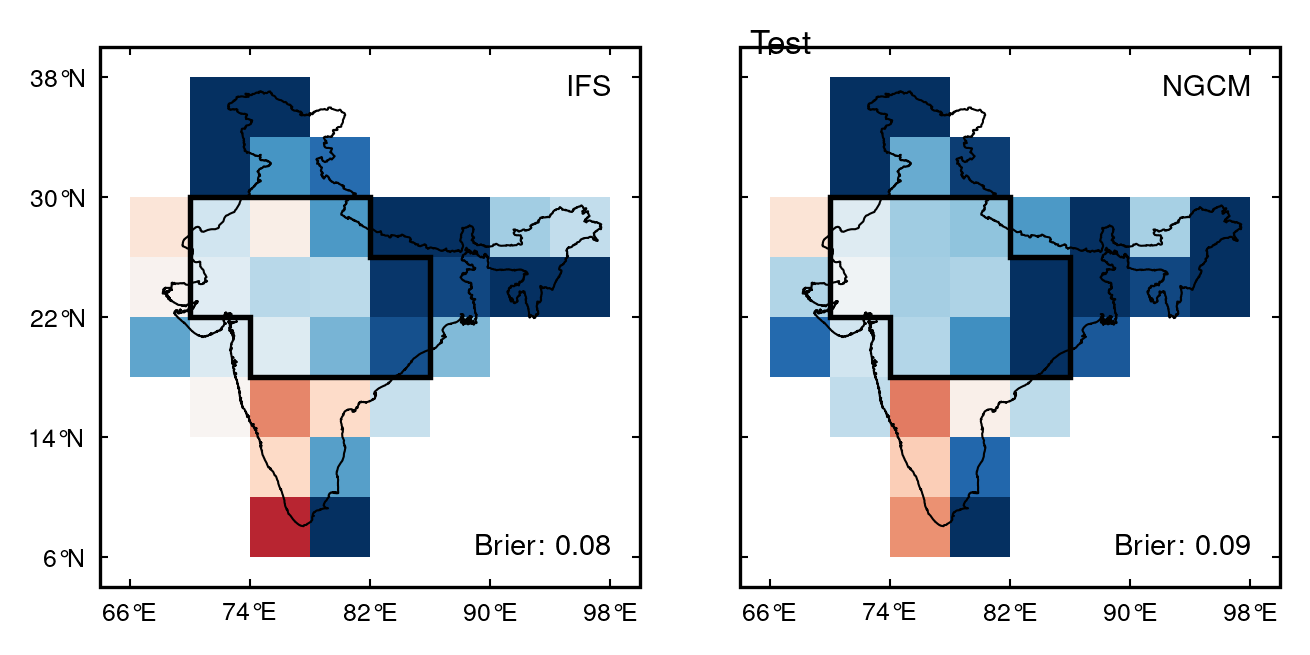

<Figure size 3600x1200 with 0 Axes>

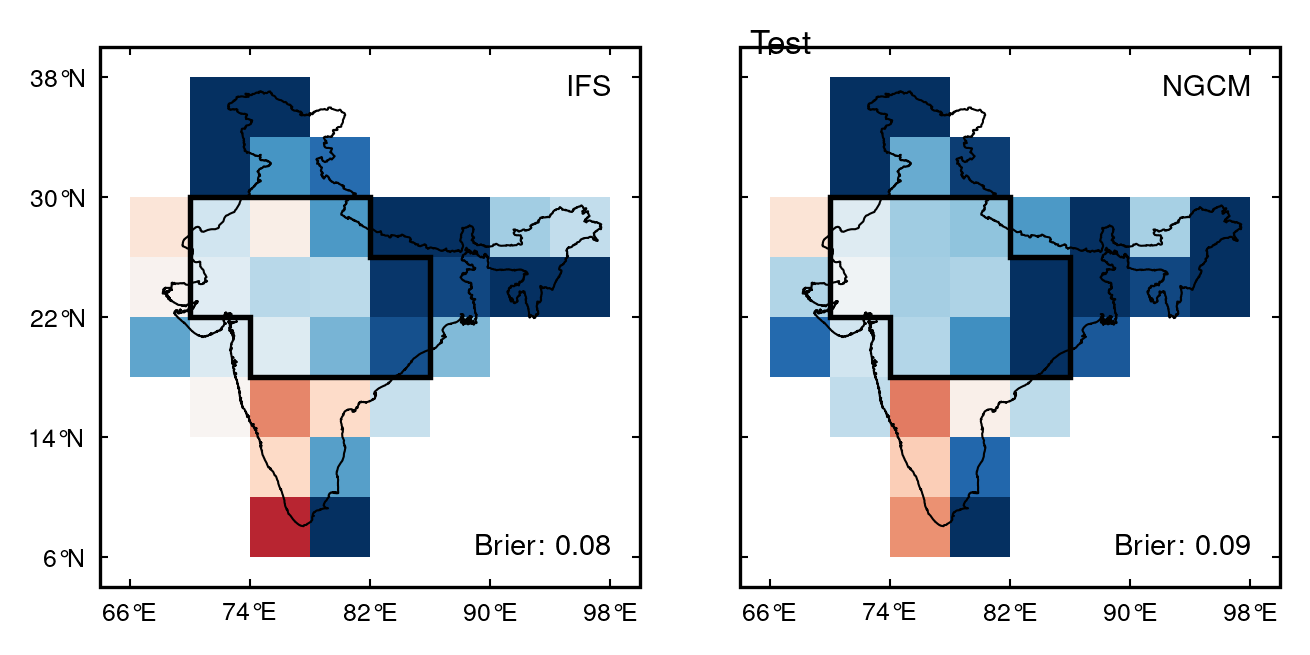

In [11]:
create_brier_rps_side_by_side(
    brier_15_ds,
    metric="brier_score",
    figure_title="Test",
    cmap="RdBu"
)

In [12]:
brier_levels = np.arange(0,0.2,0.02)
rps_levels = np.arange(0,0.5,0.05)


def create_skill_maps_figure_from_datasets(
    datasets_list: list[dict],
    figsize=(12, 16),
):
    """
    Create multi-row skill maps figure using create_brier_rps_side_by_side framework
    
    Parameters:
    -----------
    datasets_list : list of dict
        List of dictionaries, one per row: [{model: dataset, model: dataset}, {...}, ...]
        Example: [
            {'GenCast': gencast_brier_15, 'FUXI': fuxi_brier_15, 'GraphCast': gc_brier_15},
            {'GenCast': gencast_brier_30, 'FUXI': fuxi_brier_30, 'GraphCast': gc_brier_30},
            {'GenCast': gencast_rps_15, 'FUXI': fuxi_rps_15, 'GraphCast': gc_rps_15},
            {'GenCast': gencast_rps_30, 'FUXI': fuxi_rps_30, 'GraphCast': gc_rps_30}
        ]
    figsize : tuple
        Figure size (width, height)
    save_prefix : str
        Prefix for saved files (e.g., 'fig6' -> 'fig6.png', 'fig6.pdf')
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
    data_arrays : list of lists
        The data arrays used in each row
    """

    titles = {
        0: '(a) Brier Skill Score: 15-day forecast',
        1: '(b) Brier Skill Score: 30-day forecast', 
        2: '(c) Ranked Probability Skill Score: 15-day forecast',
        3: '(d) Ranked Probability Skill Score: 30-day forecast'
    }
    
    row_configs = [
        ('brier_score', 15),
        ('brier_score', 30),
        ('rps', 15),
        ('rps', 30)
    ]
    
    
    n_rows = len(datasets_list)
    n_models = len(list(datasets_list[0].keys()))
    n_cols = n_models + 1
    # Create the main figure
    fig = plt.figure(figsize=(6, 4 * n_rows / 2), dpi=300)
    
    # Width ratios: equal for maps, small for colorbar
    width_ratios = [1] * n_models + [0.02]
    
    # Create GridSpec
    gs = GridSpec(
        n_rows, n_cols,
        figure=fig,
        hspace=0.15,
        wspace=-0.2,
        left=0.05,
        right=0.85,
        top=0.95,
        bottom=0.05,
        width_ratios=width_ratios
    )
    
    # Storage for axes and data
    axes = []
    data_arrays = []
    colorbars_data = []
    
    # Process each row
    for row_idx, (metric, horizon) in enumerate(row_configs):
        row_axes = []
        row_data = []
        
        # Choose levels based on metric
        if 'brier' in metric:
            levels = brier_levels
        else:  # RPS
            levels = rps_levels
        
        # Get the data dictionary for this row
        plot_data = datasets_list[row_idx]
        
        # Create axes for this row and plot
        im = None
        for model_idx, (model, data_array) in enumerate(plot_data.items()):
            # Create axis
            ax = fig.add_subplot(gs[row_idx, model_idx], 
                               projection=ccrs.PlateCarree())
            row_axes.append(ax)
            row_data.append(data_array)
            
            # Determine labels
            show_ylabel = (model_idx == 0)
            show_xlabel = (row_idx == n_rows - 1)
            
            # Add row title to first panel only
            title = titles.get(row_idx) if (titles and model_idx == 0) else None
            
            # Create the map with discrete levels
            result = create_skill_map_panel_xr(
                ax, data_array[metric], model, metric,
                vmin=None,
                vmax=None,
                show_ylabel=show_ylabel,
                show_xlabel=show_xlabel,
                cmap='RdBu',
                levels=levels,
                title=title
            )
            
            # Store colorbar data from first model in each row
            if model_idx == 0 and result is not None:
                if isinstance(result, tuple):
                    im, used_levels = result
                else:
                    im = result
                    used_levels = levels
                colorbars_data.append((row_idx, im, metric, used_levels))
            
            # ax.set_aspect('equal', adjustable='box')
        
        axes.append(row_axes)
        data_arrays.append(row_data)
    
    if len(colorbars_data) >= 2:
        brier_data = [item for item in colorbars_data if 'brier' in item[2]]
        if brier_data:
            _, im, _, levels = brier_data[0]
            
            # Get positions of first and second row
            pos_row0 = axes[0][0].get_position()
            pos_row1 = axes[1][0].get_position()
            
            # Calculate the gap between the two rows
            gap_between_rows = pos_row1.y1 - pos_row0.y0
            
            # Calculate colorbar height (80% of the span to leave some padding)
            colorbar_height = (pos_row0.y1 - pos_row1.y0) * 0.8
            
            # Center the colorbar in the gap between rows
            center_y = (pos_row0.y1 + pos_row1.y0) / 2
            colorbar_bottom = center_y - colorbar_height / 2
            
            # Create colorbar axis centered vertically
            cax_brier = fig.add_axes([0.93, colorbar_bottom, 0.025, colorbar_height])
            cbar_brier = fig.colorbar(im, cax=cax_brier, orientation='vertical', extend='both')
            cbar_brier.set_ticks(levels[::2])  # Show every other tick
            cbar_brier.set_label('Brier Score', fontsize=MEDIUM_SIZE, rotation=270, labelpad=15)
            cbar_brier.ax.tick_params(labelsize=SMALL_SIZE, length=2, width=1)
    
    # Create ONE shared colorbar for RPS rows (2 and 3)
    if len(colorbars_data) >= 4:
        rps_data = [item for item in colorbars_data if 'rps' in item[2]]
        if rps_data:
            _, im, _, levels = rps_data[0]
            
            # Get positions of third and fourth row
            pos_row2 = axes[2][0].get_position()
            pos_row3 = axes[3][0].get_position()
            
            # Calculate colorbar height (80% of the span to leave some padding)
            colorbar_height = (pos_row2.y1 - pos_row3.y0) * 0.8
            
            # Center the colorbar in the gap between rows
            center_y = (pos_row2.y1 + pos_row3.y0) / 2
            colorbar_bottom = center_y - colorbar_height / 2
            
            # Create colorbar axis centered vertically
            cax_rps = fig.add_axes([0.93, colorbar_bottom, 0.025, colorbar_height])
            cbar_rps = fig.colorbar(im, cax=cax_rps, orientation='vertical', extend='both')
            cbar_rps.set_ticks(levels[::2])  # Show every other tick
            cbar_rps.set_label('RPS', fontsize=MEDIUM_SIZE, rotation=270, labelpad=15)
            cbar_rps.ax.tick_params(labelsize=SMALL_SIZE, length=2, width=1)
    # plt.tight_layout()

    return fig, data_arrays



(<Figure size 1800x2400 with 10 Axes>,
 [[<xarray.Dataset> Size: 1kB
   Dimensions:           (lat: 8, lon: 8)
   Coordinates:
     * lat               (lat) float64 64B 8.0 12.0 16.0 20.0 24.0 28.0 32.0 36.0
     * lon               (lon) float64 64B 68.0 72.0 76.0 80.0 84.0 88.0 92.0 96.0
   Data variables:
       brier_score       (lat, lon) float64 512B nan nan 0.01439 ... nan nan nan
       fair_brier_score  (lat, lon) float64 512B nan nan 0.01326 ... nan nan nan,
   <xarray.Dataset> Size: 1kB
   Dimensions:           (lat: 8, lon: 8)
   Coordinates:
     * lat               (lat) float64 64B 8.0 12.0 16.0 20.0 24.0 28.0 32.0 36.0
     * lon               (lon) float64 64B 68.0 72.0 76.0 80.0 84.0 88.0 92.0 96.0
   Data variables:
       brier_score       (lat, lon) float64 512B nan nan 0.03272 ... nan nan nan
       fair_brier_score  (lat, lon) float64 512B nan nan 0.02797 ... nan nan nan],
  [<xarray.Dataset> Size: 1kB
   Dimensions:           (lat: 8, lon: 8)
   Coordinates:
  

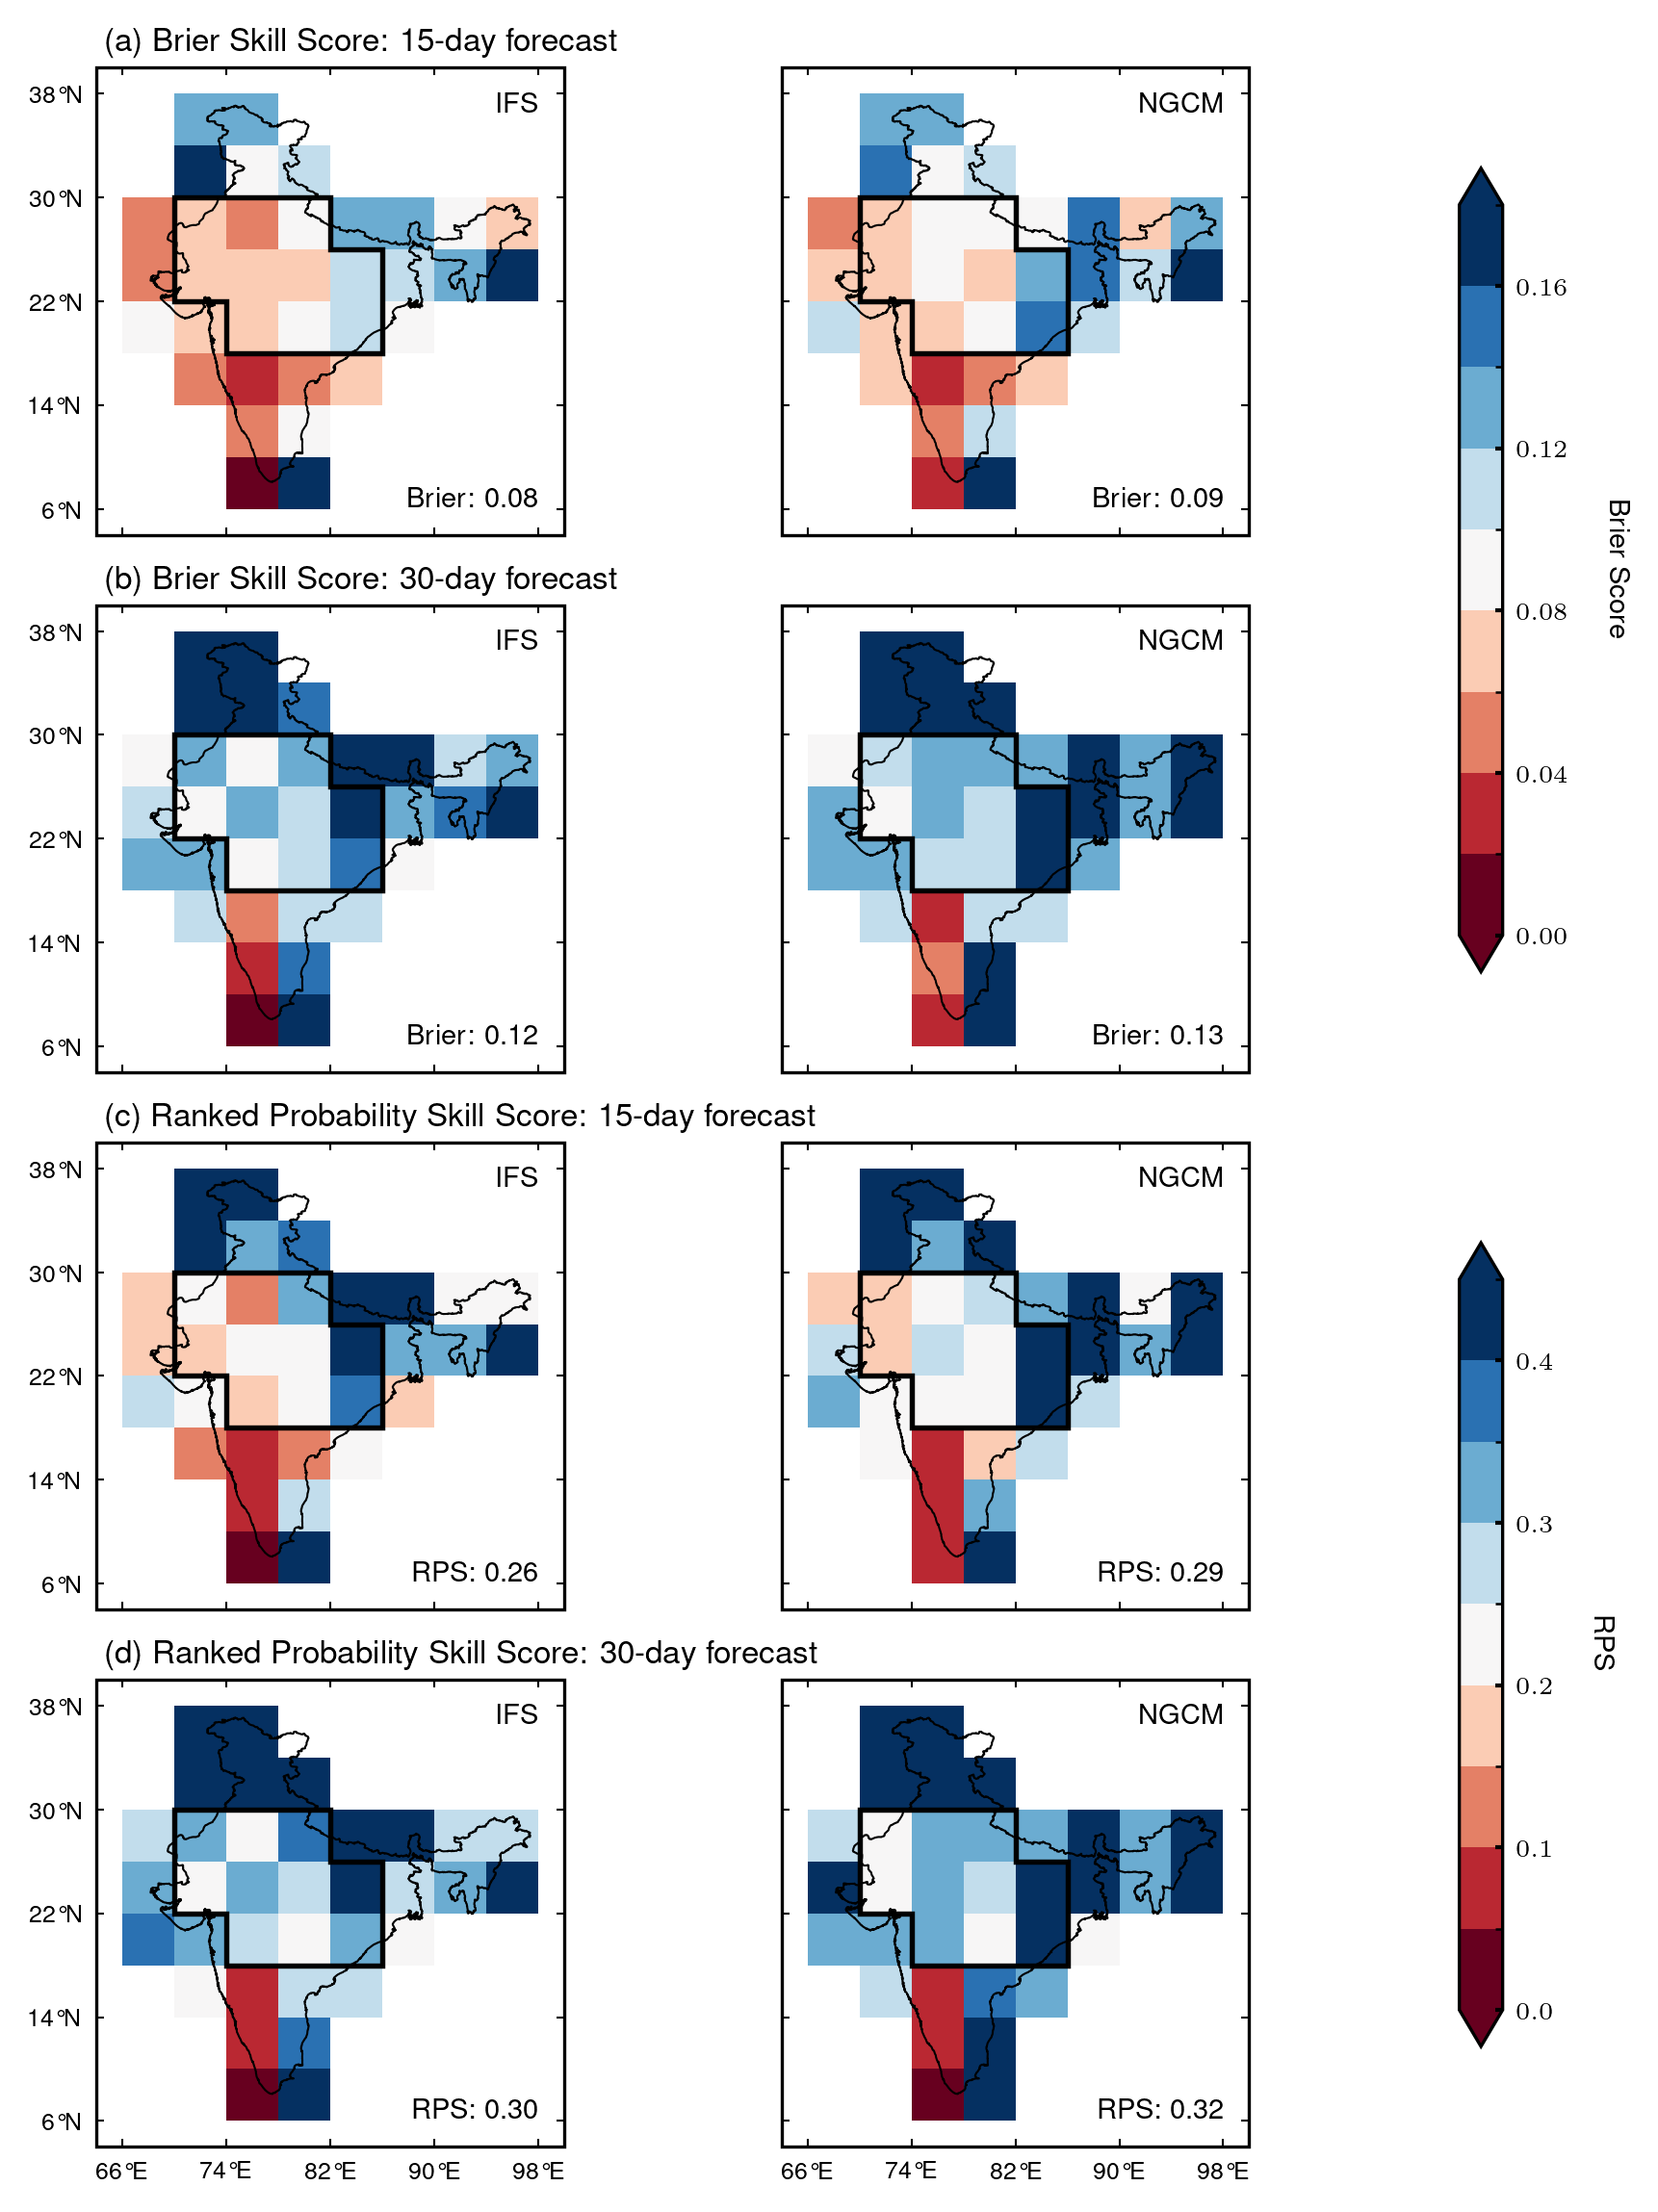

In [13]:
test_data = [
    brier_15_ds,
    brier_30_ds,
    rps_15_ds,
    rps_30_ds
]

create_skill_maps_figure_from_datasets(test_data)

In [14]:
climatology = ClimatologyOnsetMetrics()

metrics_df_clim, onset_da_clim = climatology.compute_climatology_baseline_multiple_years(
    years=config["alt_recent_years"],
    imd_folder=config["imd_folder"],
    thres_file=config["thresh_file"],
    tolerance_days=3,
    verification_window=1,
    forecast_days=15,
    max_forecast_day=15,
    mok=True,
    onset_window=5,
    mok_month=6,
    mok_day=2,
)

spatial_clim = climatology.create_spatial_far_mr_mae(
    metrics_df_clim,
    dict.fromkeys(config["alt_recent_years"], onset_da_clim)
)

Computing climatological onset reference...
Computing climatological onset from 124 years: 1901-2024
Loading IMD rainfall from: /Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data/imd_rainfall_data/4p0/1901.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1901-06-02) as start date for onset detection
Loading IMD rainfall from: /Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data/imd_rainfall_data/4p0/1902.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1902-06-02) as start date for onset detection
Loading IMD rainfall from: /Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data/imd_rainfall_data/4p0/1903.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (1903-06-02) as start date for onset detection
Loading IMD rainfall from: /Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data/imd_rainfall_data/4p0/1904.nc
Renamed dimensions: {'TIME': 'time'}
Using MO

Detected resolution: 4.0 degrees
Using 4-degree CMZ polygon coordinates

=== CORE MONSOON ZONE (CMZ) AVERAGES ===
CMZ Mean MAE (avg across years): 7.52 ± 1.20 days
CMZ False Alarm Rate: 19.4 %
CMZ Miss Rate: 50.2 %


(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: xlabel='Longitude', ylabel='Latitude'>,
        <Axes: xlabel='Longitude'>, <Axes: xlabel='Longitude'>],
       dtype=object))

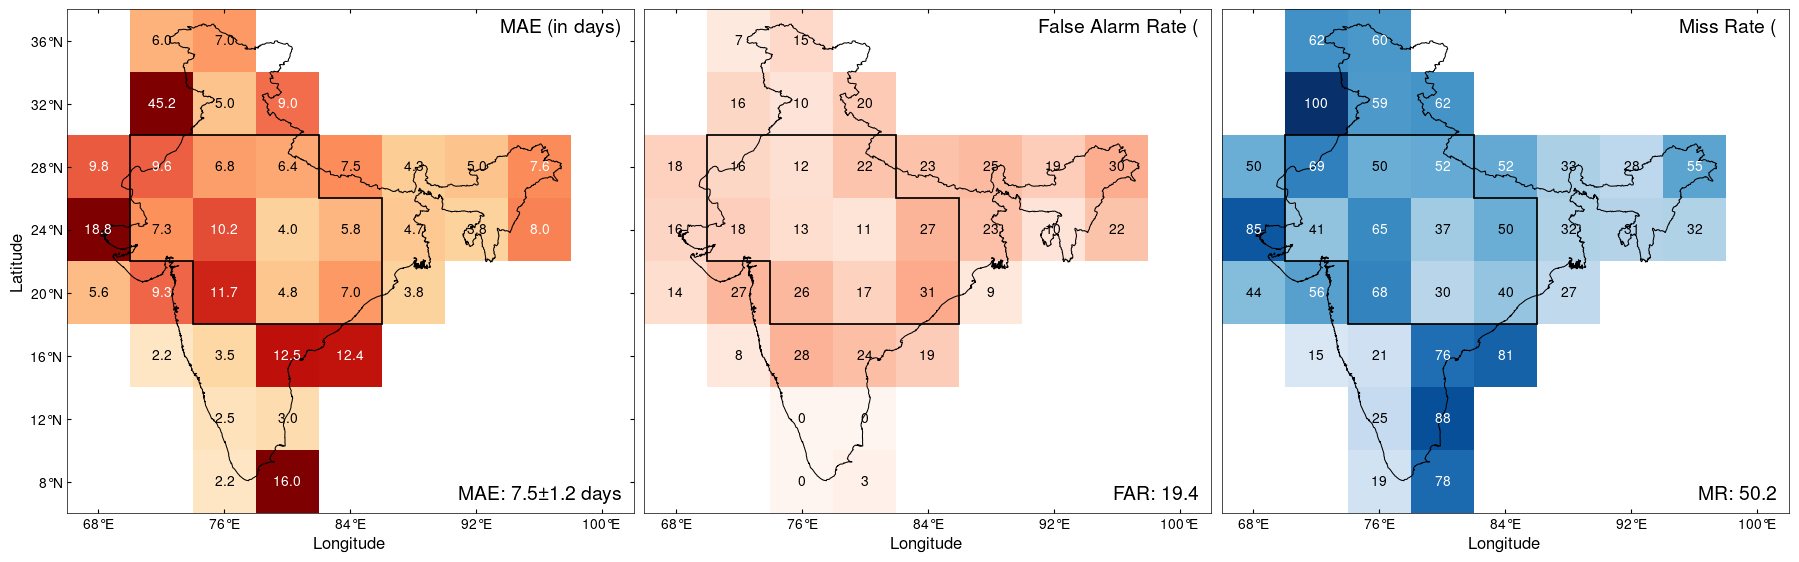

In [15]:
climatology.plot_spatial_metrics(
    spatial_clim,
    config["india_shpfile"]
)

In [16]:
determenistic = DeterministicOnsetMetrics()
error_models = []

for model_name, model_fp in det_model_paths.items():
    try:
        probabilistic_df, onset_da_dict = determenistic.compute_metrics_multiple_years(
                years=config["alt_recent_years"],
                imd_folder=config["imd_folder"],
                thres_file=config["thresh_file"],
                model_forecast_dir=model_fp,
                tolerance_days=3,
                verification_window=1,
                forecast_days=15,
                max_forecast_day=15,
                mok=True,
                onset_window=5,
                mok_month=6,
                mok_day=2,
            )
        model_dfs[model_name] = probabilistic_df
        model_onsets[model_name] = onset_da_dict
    except:
        error_models.append(model_name)

print(error_models)


Processing year 2013
p_model dims: ('day', 'init_time', 'lat', 'lon')
p_model sizes: {'day': 45, 'init_time': 26, 'lat': 8, 'lon': 9}
Loading IMD rainfall from: /Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data/imd_rainfall_data/4p0/2013.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (2013-06-02) as start date for onset detection
Processing 26 init times x 8 lats x 9 lons...
Using MOK (6/2 filter) for onset detection
Only processing forecasts initialized before observed onset dates
Processing init time 1/26: 2013-05-02
Processing init time 6/26: 2013-05-20
Processing init time 11/26: 2013-06-06
Processing init time 16/26: 2013-06-24
Processing init time 21/26: 2013-07-11
Processing init time 26/26: 2013-07-29

Processing Summary:
Total potential initializations: 1872
Skipped (no observed onset): 962
Skipped (initialized after observed onset): 465
Valid initializations processed: 445
Onsets found: 190
Onset rate: 0.427
Computing onset metrics 

In [17]:
probabilistic = ProbabilisticOnsetMetrics()
error_models = []

for model_name, model_fp in prob_model_paths.items():
    try:
        probabilistic_df, onset_da_dict = probabilistic.compute_metrics_multiple_years(
                years=config["alt_recent_years"],
                imd_folder=config["imd_folder"],
                thres_file=config["thresh_file"],
                model_forecast_dir=model_fp,
                tolerance_days=3,
                verification_window=1,
                forecast_days=15,
                max_forecast_day=15,
                mok=True,
                onset_window=5,
                mok_month=6,
                mok_day=2,
            )
        model_dfs[model_name] = probabilistic_df
        model_onsets[model_name] = onset_da_dict
    except:
        error_models.append(model_name)

print(error_models)


Processing year 2013
Loading IMD rainfall from: /Users/charlieeden/Desktop/Winter 2026/ds_clinic_2/monsoon-benchmark_data/imd_rainfall_data/4p0/2013.nc
Renamed dimensions: {'TIME': 'time'}
Using MOK date (June 2nd) (2013-06-02) as start date for onset detection
Processing 26 init times x 8 lats x 9 lons...
Using MOK (6/2 filter) for onset detection
Only processing forecasts initialized before observed onset dates
Requiring ≥50% of 11 members to have onset for ensemble onset
Processing init time 1/26: 2013-05-02
Processing init time 6/26: 2013-05-20
Processing init time 11/26: 2013-06-06
Processing init time 16/26: 2013-06-24
Processing init time 21/26: 2013-07-11
Processing init time 26/26: 2013-07-29

Processing Summary:
Total potential initializations: 1872
Skipped (no observed onset): 962
Skipped (initialized after observed onset): 465
Valid initializations processed: 445
Ensemble onsets found (≥50% members): 182
Ensemble onset rate: 0.409
Note: Only onsets on or after 6/2 were cou

In [18]:
prob_plot_data = {}
for model_name in model_dfs.keys():
    probabilistic_df = model_dfs[model_name]
    onset_da_dict = model_onsets[model_name]
    plot_probabilistic_metrics = determenistic.create_spatial_far_mr_mae(
        probabilistic_df, onset_da_dict
    )
    prob_plot_data[model_name] = plot_probabilistic_metrics

prob_plot_data["Climatology"] = spatial_clim

Creating spatial FAR, Miss Rate, yearly MAE, and mean MAE maps...
Grid dimensions: 8 lats x 9 lons
Years: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
Creating spatial FAR, Miss Rate, yearly MAE, and mean MAE maps...
Grid dimensions: 8 lats x 9 lons
Years: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
Creating spatial FAR, Miss Rate, yearly MAE, and mean MAE maps...
Grid dimensions: 8 lats x 9 lons
Years: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
Creating spatial FAR, Miss Rate, yearly MAE, and mean MAE maps...
Grid dimensions: 8 lats x 9 lons
Years: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]
Creating spatial FAR, Miss Rate, yearly MAE, and mean MAE maps...
Grid dimensions: 8 lats x 9 lons
Years: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), n

In [19]:
# Define the models and metrics to plot
models = prob_plot_data.keys()
metrics = prob_plot_data["AIFS"].keys()
horizons = [15, 30]  # 15-day and 30-day horizons

model_labels = {}
for i in models:
    model_labels[i] = i

# Plot configuration
SMALL_SIZE = 6
MEDIUM_SIZE = 7
LARGE_SIZE = 8

# Define Core Monsoon Zone polygon (same as reference)
polygon1_lon = np.array([86, 74, 74, 70, 70, 82, 82, 86, 86])
polygon1_lat = np.array([18, 18, 22, 22, 30, 30, 26, 26, 18])

panel_linewidth = 0.5
map_lw = 0.5
polygon_lw = 1.3
tick_length = 2
tick_width = 0.5

In [20]:
# Create map instance graph
def create_skill_map_panel_xr(ax, data_array, model,
                              metric:str,
                              vmin=-100, vmax=100, show_ylabel=True,
                              show_xlabel=True,
                              title=None,
                              levels=None,
                              cmap='YlOrRd'
                              ):
    """
    Create a skill map panel using xarray DataArray with India boundaries
    """
    
    if data_array.isnull().all():
        ax.text(0.5, 0.5, f'No data for {model}', 
                transform=ax.transAxes, ha='center', va='center')
        return None
    
    # Get coordinates
    lats = data_array.lat.values
    lons = data_array.lon.values
    
    # Create edges for pcolormesh
    lat_edges = np.concatenate([lats - 2, [lats[-1] + 2]])
    lon_edges = np.concatenate([lons - 2, [lons[-1] + 2]])

    # Create discrete colormap and normalization
    if levels is not None:
        cmap, norm = create_discrete_colormap(levels, cmap)
        vmin, vmax = None, None  # Let norm handle the range
    else:
        cmap = cmap
        norm = None
        vmin, vmax = vmin, vmax
    
    # Create pcolormesh plot
    im = ax.pcolormesh(lon_edges, lat_edges, data_array.values,
                      transform=ccrs.PlateCarree(),
                      cmap=cmap, norm=norm, vmin=vmin, vmax=vmax, shading='flat')
    
    # for i, lat in enumerate(lats):
    #     for j, lon in enumerate(lons):
    #         value = data_array.values[i, j]
    #         if not np.isnan(value):
    #             ax.text(
    #                 lon, lat,                   # position in map coordinates
    #                 f"{value:.2f}",             # format the value
    #                 color="black",              # text color (choose 'white' if background is dark)
    #                 fontsize=6,                 # adjust size to fit
    #                 ha="center", va="center"    # center text in the cell
    #             )
    
    # Add India boundaries using the get_india_outline function
    try:
        india_boundaries = get_india_outline(
            shp_file_path=config["india_shpfile"]
        )
        for boundary in india_boundaries:
            india_lon, india_lat = boundary
            ax.plot(india_lon, india_lat, color='black', linewidth=map_lw, 
                   transform=ccrs.PlateCarree())
    except Exception as e:
        print(f"Warning: Could not load India boundaries: {e}")
        # Fallback to coastlines if India outline fails
        ax.add_feature(cfeature.COASTLINE, linewidth=map_lw, color='black')
    
    # Add Core Monsoon Zone polygon
    polygon = Polygon(list(zip(polygon1_lon, polygon1_lat)), 
                     fill=False, edgecolor='black', linewidth=polygon_lw,
                     transform=ccrs.PlateCarree())
    ax.add_patch(polygon)
    
    # Calculate average value inside the polygon
    from matplotlib.path import Path
    polygon_path = Path(list(zip(polygon1_lon, polygon1_lat)))
    
    # Find grid points inside the polygon
    values_in_polygon = []
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            if polygon_path.contains_point((lon, lat)):
                value = data_array.values[i, j]
                if not np.isnan(value):
                    values_in_polygon.append(value)
    
    
    # Calculate and display average
    if values_in_polygon:
        avg_value = np.mean(values_in_polygon)
        cmz_text = cmz_text_formatter(val=avg_value,
                                      metric=metric)
        # Add average value text in bottom-right corner
        ax.text(0.95, 0.05, cmz_text, 
                transform=ax.transAxes,
                horizontalalignment='right', verticalalignment='bottom',
                color='black', fontsize=MEDIUM_SIZE, fontweight='normal')
    
    # Add model name text in top-right using the mapped label
    model_label = model_labels.get(model, model.upper())
    ax.text(0.95, 0.95, model_label, transform=ax.transAxes,
            horizontalalignment='right', verticalalignment='top',
            color='black', fontsize=MEDIUM_SIZE, fontweight='normal')
    
 
    # Set axis limits and ticks
    ax.set_xlim([lons[0]-4, 100])
    ax.set_ylim([lats[0]-4, lats[-1]+4])
    
    # Create tick labels
    yticks = np.arange(lats[0]-2, lats[-1]+3, 8)
    yticklabels = [f"{int(y)}°N" if i % 1 == 0 else "" for i, y in enumerate(yticks)]
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    if show_ylabel:
        ax.set_yticklabels(yticklabels)
    else:
        ax.set_yticklabels([])
    
    xticks = np.arange(lons[0]-2, lons[-1]+3, 8)
    xticklabels = [f"{int(x)}°E" if i % 1 == 0 else "" for i, x in enumerate(xticks)]
    ax.set_xticks(xticks)
    if show_xlabel:
        ax.set_xticklabels(xticklabels)
    else:
        ax.set_xticklabels([])
    
    # Styling
    ax.tick_params(axis='both', which='major', labelsize=SMALL_SIZE, 
                  length=tick_length, width=tick_width)
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_linewidth(panel_linewidth)
    
    # Remove grid lines
    ax.grid(False)
    ax.set_axisbelow(False)
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    ax.tick_params(axis='y', which='minor', left=False, right=False)
    
    if title:
        ax.text(0.02, 1.02, title, transform=ax.transAxes, 
                verticalalignment='bottom', fontsize=LARGE_SIZE, fontweight='normal')
    
    return im, levels

(<cartopy.mpl.geocollection.GeoQuadMesh at 0x122d31310>, None)

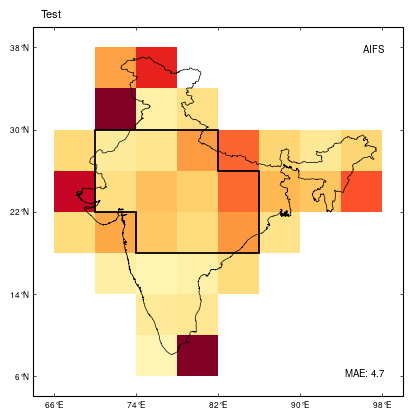

In [21]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
create_skill_map_panel_xr(
    ax=ax,
    data_array=prob_plot_data["AIFS"]["mean_mae"],
    model="AIFS",
    metric="mean_mae",
    title="Test",
    vmin=0,
    vmax=15,
)

In [22]:
# Create grid of map instances function

def create_skill_maps_figure_xr(plot_data: dict[str,xr.Dataset],
                              metric:str,
                              forecast_days: int,
                              vmin:float=None,
                              vmax:float=None,
                              figure_title:str=None,
                              cmap="YlOrRd",
                              n_colors:int=10):
    """Create the complete figure using xarray DataArrays"""

    plot_data_arrays = {
        model: data[metric]
        for model, data in plot_data.items()
        }

    # Dynamic Scaling
    all_values = np.concatenate([
        da.values.flatten()
        for da in plot_data_arrays.values()
    ])

    if vmin is None:
        vmin = np.nanmin(all_values)

    if vmax is None:
        vmax = np.nanmax(all_values)

    levels = np.linspace(vmin, vmax, n_colors + 1)

    n_models = len(plot_data_arrays)
    n_cols = 2
    n_rows = int(np.ceil(n_models / n_cols))

    
    # # Create the main figure
    fig = plt.figure(figsize=(6, 4 * n_rows / 2),
                     dpi=300)

    # Create GridSpec for better control - 4 rows, 10 columns
    gs = GridSpec(
    n_rows,
    n_cols + 1,
    figure=fig,
    hspace=0.05,
    wspace=-0.2,
    left=0.05,
    right=0.85,
    top=0.95,
    bottom=0.05,
    width_ratios=[1, 1, 0.08]
)

    
    axes = np.empty((n_rows, n_cols), dtype=object)

    for r in range(n_rows):
        for c in range(n_cols):
            axes[r, c] = fig.add_subplot(
                gs[r, c],
                projection=ccrs.PlateCarree()
            )

    im_for_colorbar = None
    levels_for_colorbar = None

    for i, (model, model_data) in enumerate(plot_data_arrays.items()):
        r, c = divmod(i, n_cols)
            
        # Create the map instance
        show_ylabel = (c == 0)
        show_xlabel = (r == n_rows - 1)

        result = create_skill_map_panel_xr(
            axes[r, c],
            model_data,
            model,
            metric=metric,
            vmin=vmin,
            vmax=vmax,
            show_ylabel=show_ylabel,
            show_xlabel=show_xlabel,
            cmap=cmap,
            levels=levels
        )

        axes[r, c].set_aspect('equal', adjustable='box')
        
        if result is not None and im_for_colorbar is None:
            im_for_colorbar, levels_for_colorbar = result


    for idx in range(n_models, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r, c].axis("off")

    if im_for_colorbar is not None:

        # Get positions of ALL active axes
        active_axes = [
            axes[r, c]
            for r in range(n_rows)
            for c in range(n_cols)
            if axes[r, c].axison
        ]

        positions = [ax.get_position() for ax in active_axes]

        # Find vertical span of panel grid
        top = max(p.y1 for p in positions)
        bottom = min(p.y0 for p in positions)

        panel_height = top - bottom

        # Make colorbar centered within panel area
        cbar_height = panel_height * 0.8   # adjust if you want taller/shorter
        cbar_y = bottom + (panel_height - cbar_height) / 2

        cax = fig.add_axes([
            0.87,          # horizontal position (right margin)
            cbar_y,
            0.025,
            cbar_height
        ])

        cbar = fig.colorbar(
            im_for_colorbar,
            cax=cax,
            orientation="vertical",
            extend="max",
            spacing='uniform',
            boundaries=levels_for_colorbar,
            ticks=levels_for_colorbar
        )

        cbar.set_label(metric.upper())
        cbar.ax.minorticks_off()
        cbar.ax.tick_params(length=2, width=1)


    if figure_title:
        fig.suptitle(figure_title)

    return fig


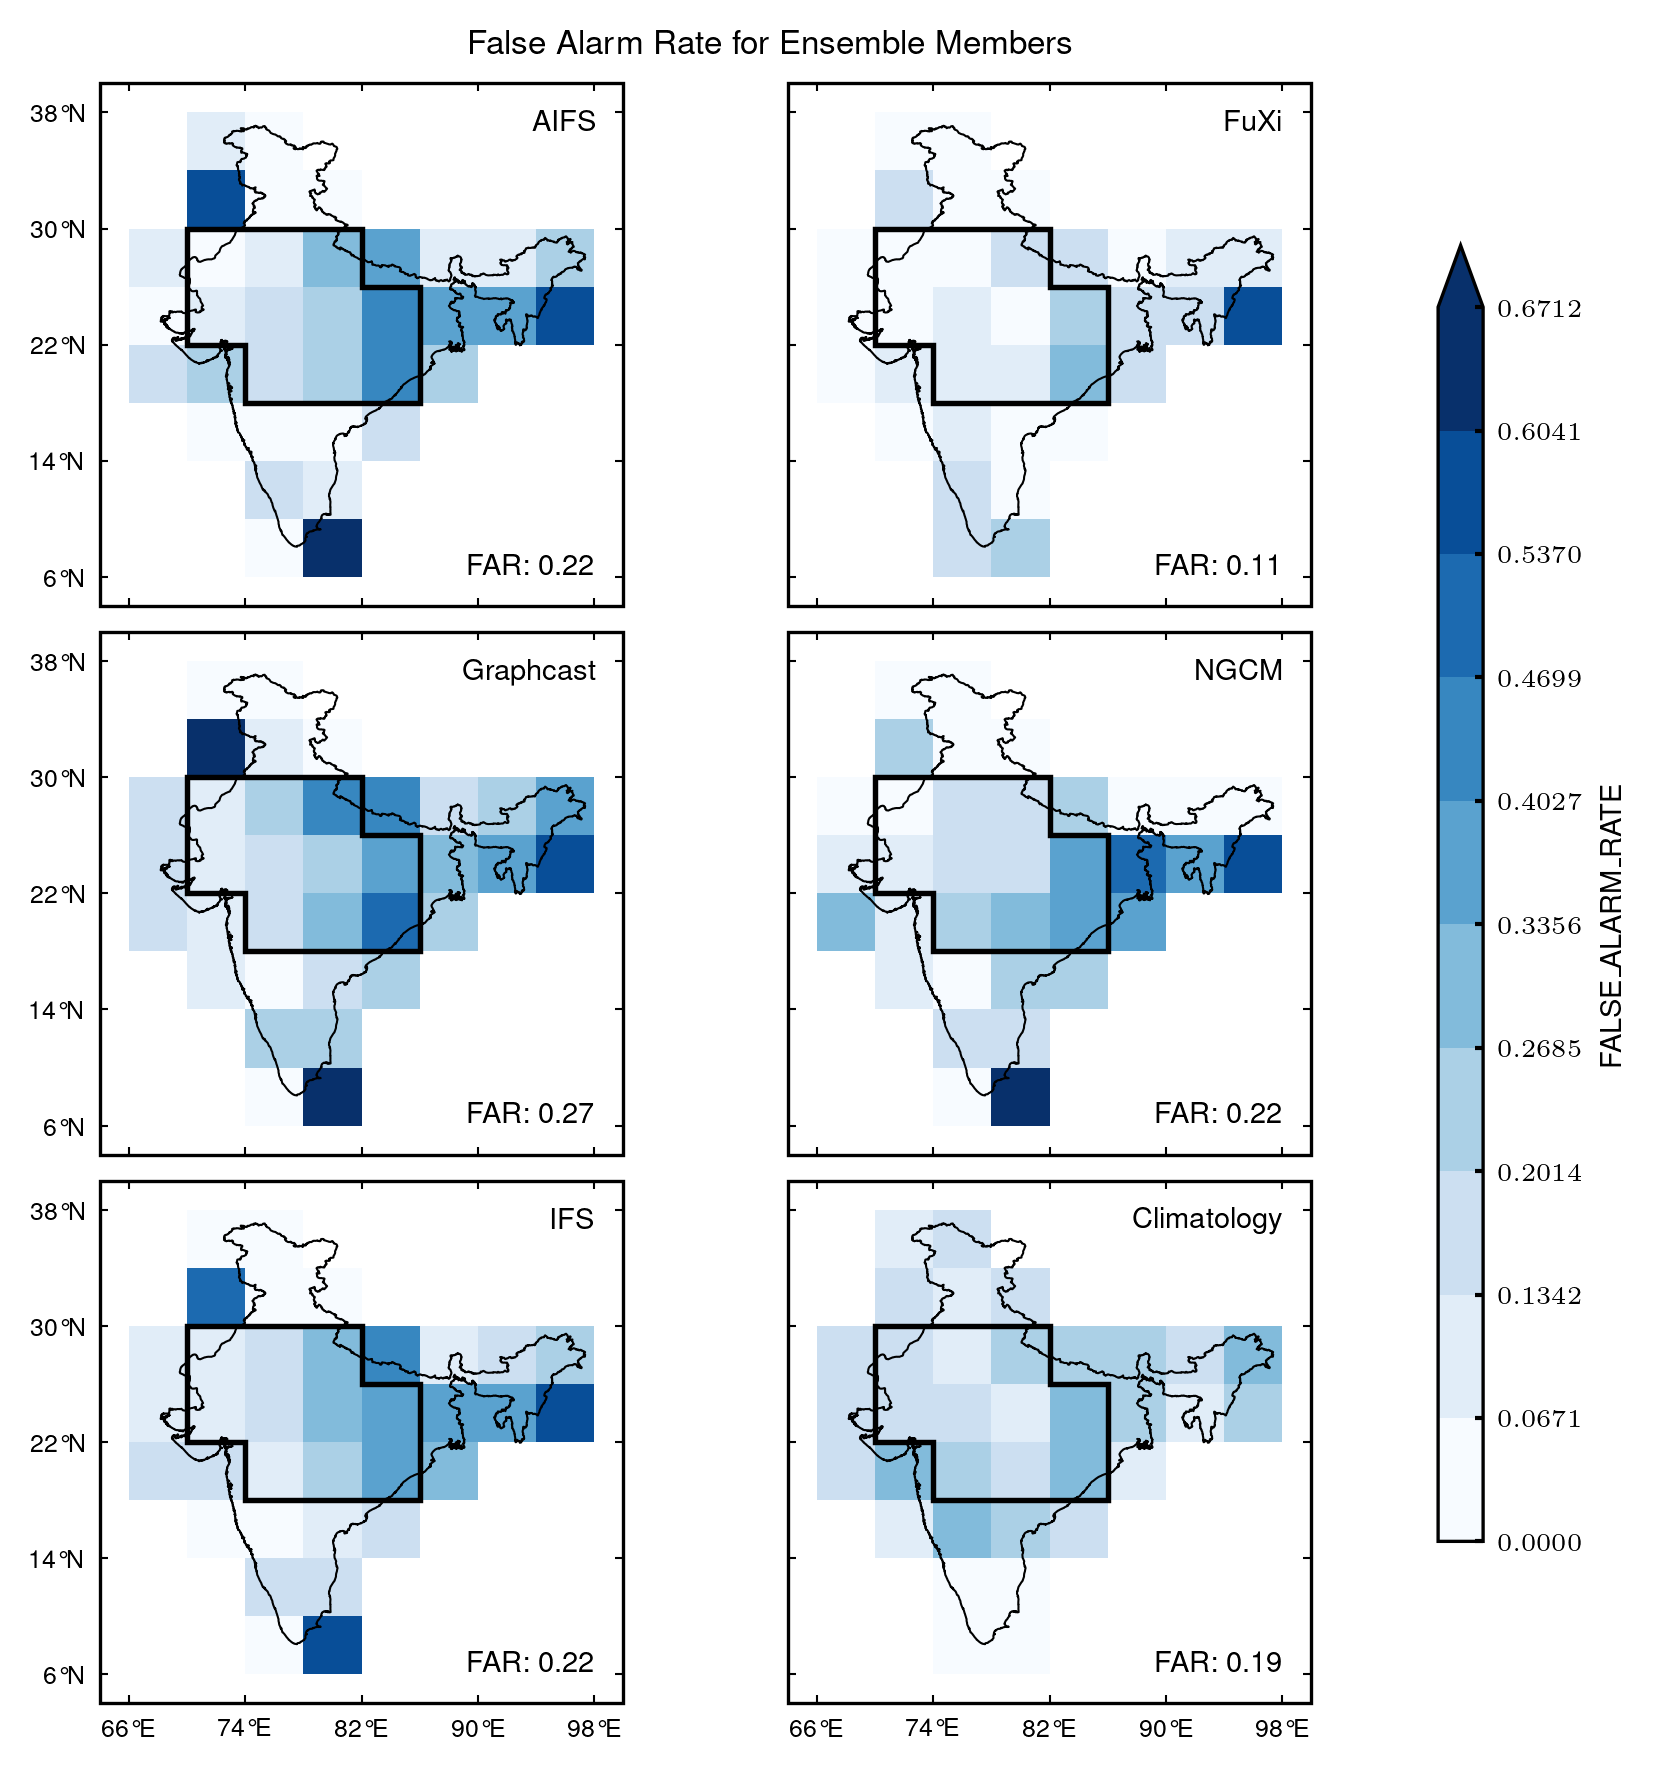

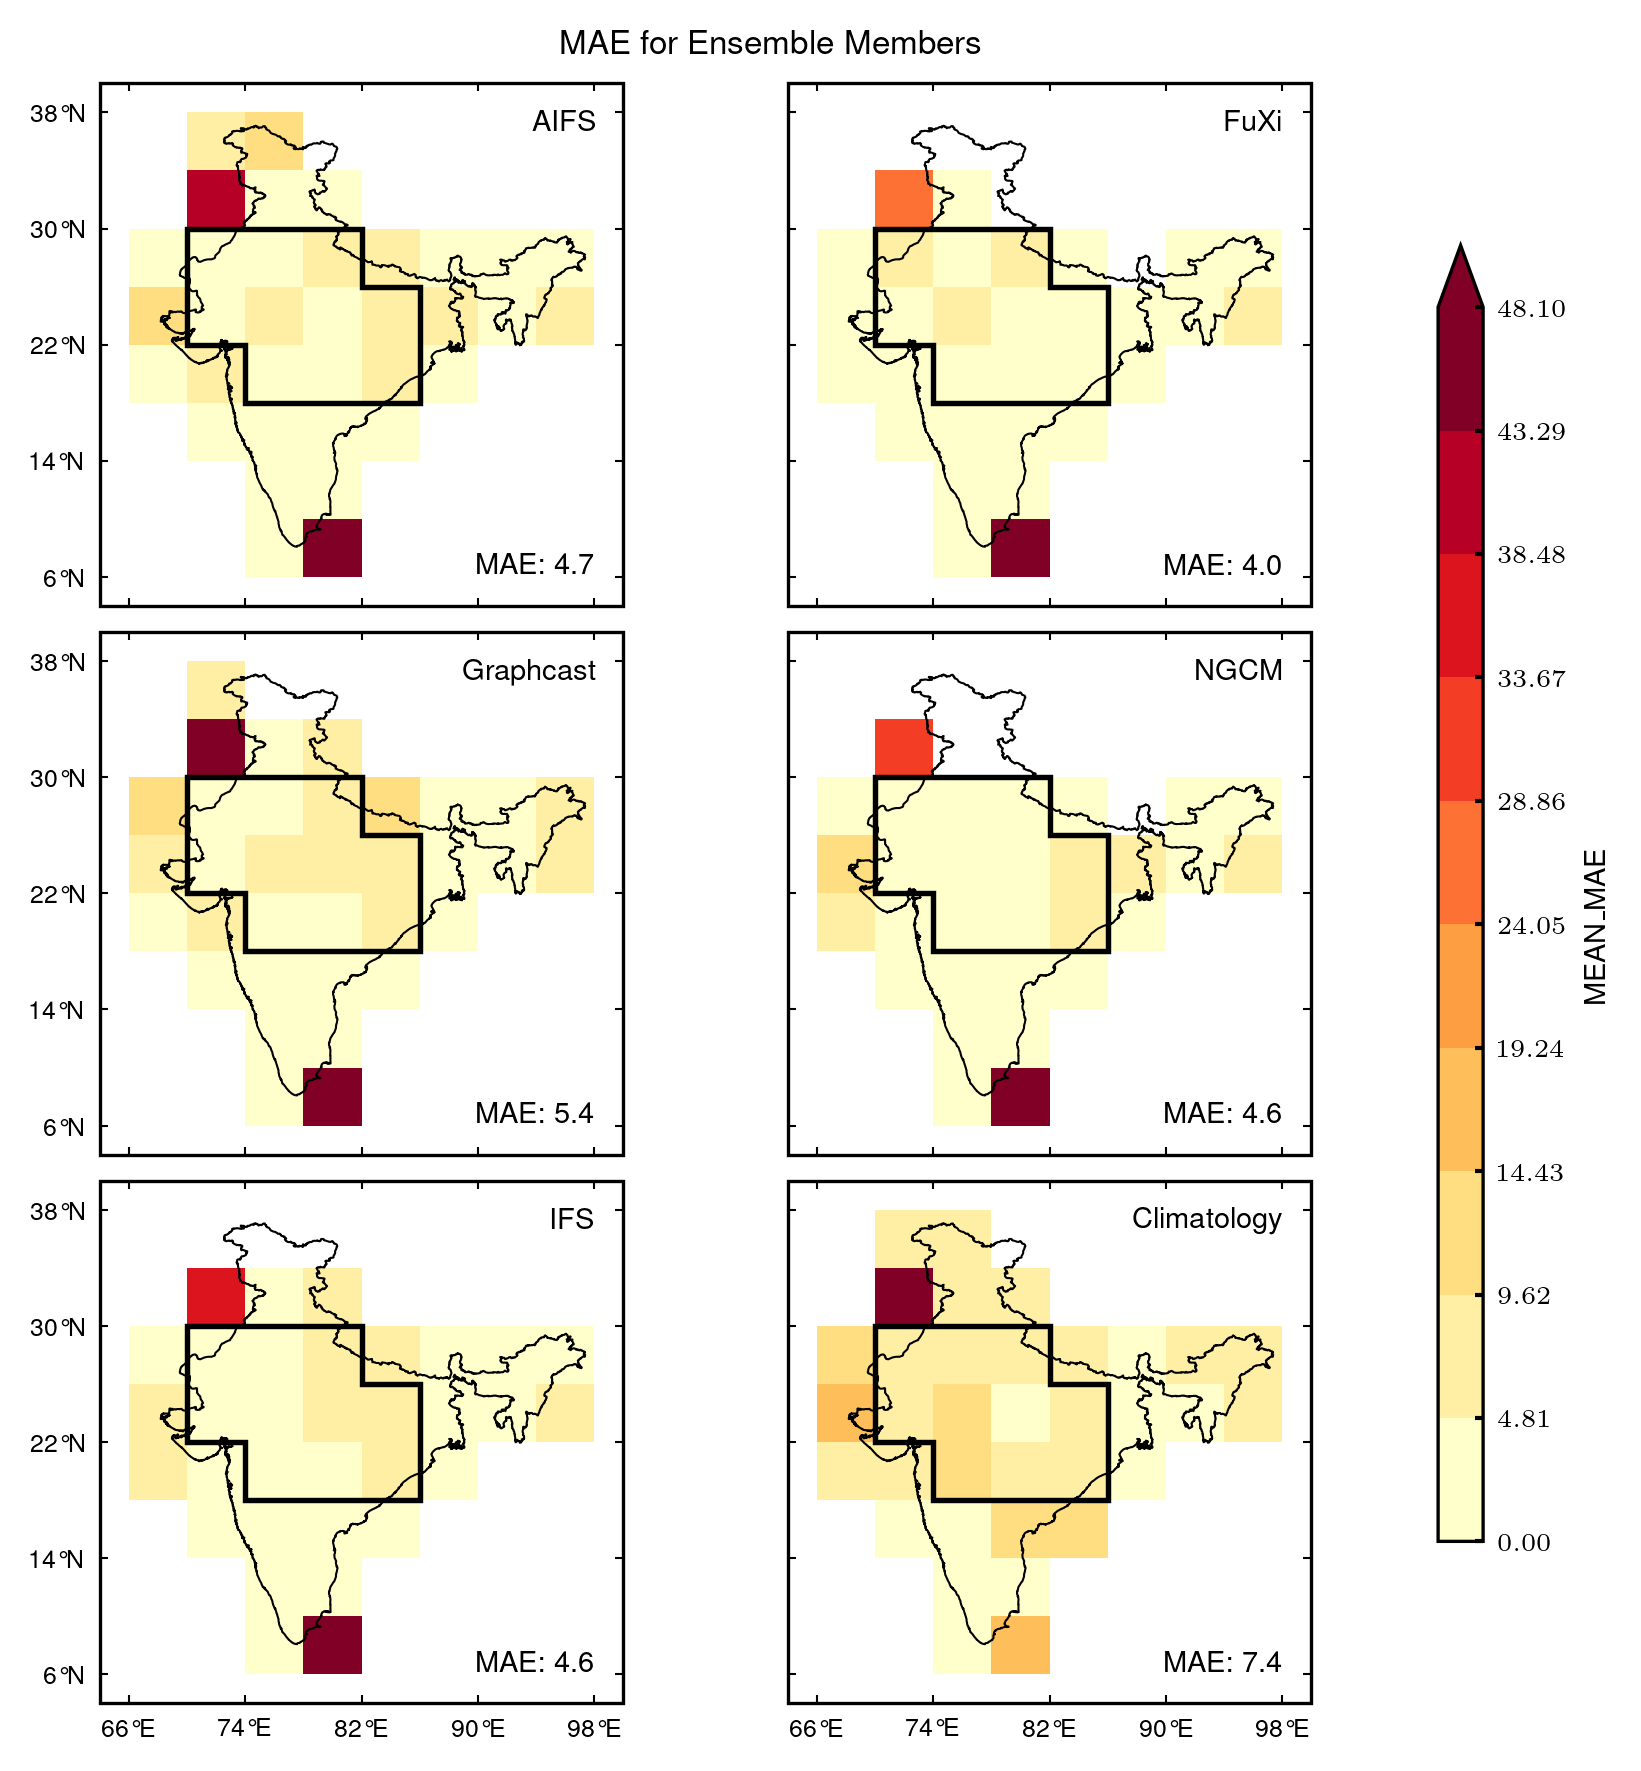

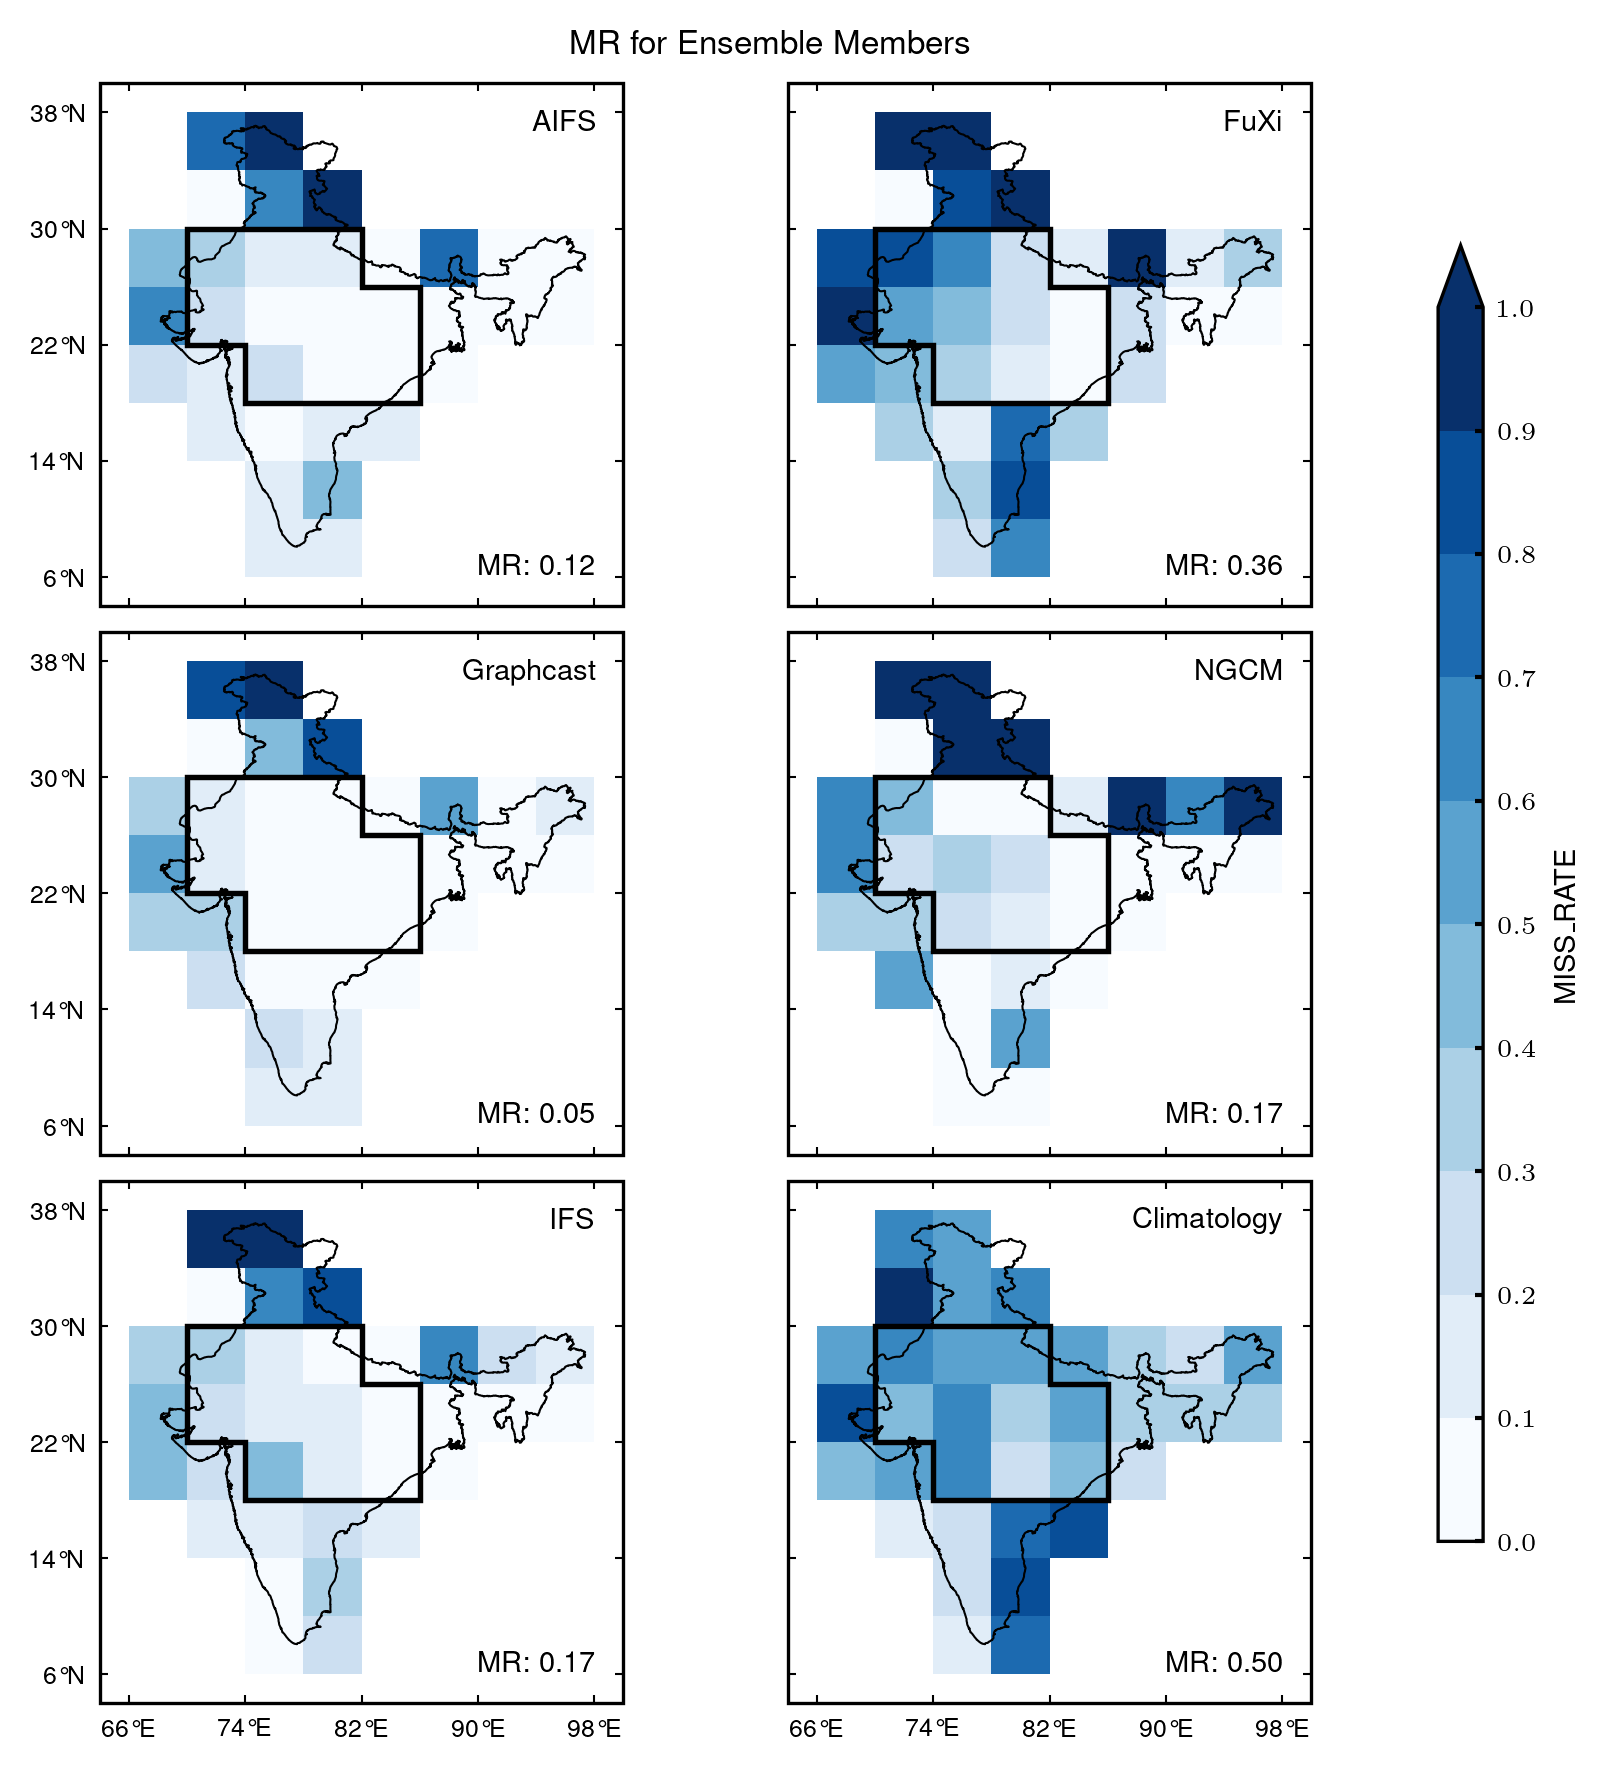

In [23]:
test_title1 = "False Alarm Rate for Ensemble Members"
test_title2 = "MAE for Ensemble Members"
test_title3 = "MR for Ensemble Members"
test_fig1 = create_skill_maps_figure_xr(
    plot_data=prob_plot_data,
    metric="false_alarm_rate",
    forecast_days=15,
    figure_title=test_title1,
    cmap="Blues"
)
test_fig2 = create_skill_maps_figure_xr(
    plot_data=prob_plot_data,
    metric="mean_mae",
    forecast_days=15,
    figure_title=test_title2
)
test_fig3 = create_skill_maps_figure_xr(
    plot_data=prob_plot_data,
    metric="miss_rate",
    forecast_days=15,
    figure_title=test_title3,
    cmap="Blues"
)